In [337]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
import japanize_matplotlib
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import auc
from IPython.display import display


In [338]:
data = pd.read_csv("7-4-18_data_new.csv", encoding="shift-jis")
# data = pd.read_csv("7-4-18_data_all.csv")

data["Q4_1"] = 6 - data["Q4_1"]
# data = data.drop(["Q16_1", "Q16_2",], axis = 1)
data = data.fillna(0)
data_filt = data.filter(regex="Q16", axis = 1)
data_filt = 5 - data_filt
# data = data.drop(["Q16_1", "Q16_2", "Q16_3", "Q16_4"], axis = 1)
# data = data.drop(["Q16_3", "Q16_4"], axis = 1)
data = pd.concat([data, data_filt], axis = 1)
# data["SQ2"] = data["SQ2"].round(-1)

# 列名の変更
data = data.rename(columns={
    "Q1": "満足度",
    "Q2_7": "正確性",
    "Q2_8": "更新頻度",
    "Q2_9": "豊富さ",
    "Q2_10": "詳細さ",
    "Q4_1": "他者推薦",
})

outcome_col = "他者推薦"
state_col = "正確性" 
score_rec = np.array([0, 1, 2, 3, 4],dtype= "float") 

th_sh = data[state_col].quantile(0.75)
# th_sh = data["豊富さ"].mean()
data["treatment"] = (data[state_col] >= th_sh).astype(int)
seg_col = "Q7_4"
#交絡因子
# cfd = ["更新頻度", "詳細さ", "正確性", "Q5_2"]
ftr_cols = [c for c in data.columns]
ftr_cols.remove("他者推薦")
ftr_cols = [i for i in ftr_cols if i not in ['正確性', '更新頻度', '詳細さ',"豊富さ"]]
ftr_cols.remove("treatment")
ftr_cols.remove(seg_col)
ftr_cols.remove("SQ2")

X = pd.get_dummies(data[ftr_cols], drop_first=False).values
A = data["treatment"].astype(int).values

levels = pd.Series(data[outcome_col]).dropna().unique().tolist()
levels_sorted = sorted(levels)  
y_to_index = {lev:i for i, lev in enumerate(levels_sorted)}
Y = pd.Series(data[outcome_col]).map(y_to_index).astype(int).values

K = len(levels_sorted)

In [339]:
def ensure_numpy(x):
    if isinstance(x, (pd.Series, pd.DataFrame)):
        return x.values
    return np.asarray(x) #numpy配列に変換

def clip_eps(arr, eps=1e-4):
    return np.clip(arr, eps, 1 - eps) #指定範囲でクリッピング

In [340]:
def proba_aligned(estimator, X_va, K):
    """
    確率予測(predict_proba) が (n,k_obs) でも K 列に整列。
    欠落クラスは0で埋め、行正規化（全ゼロ行は一様）。
    """
    p_raw = estimator.predict_proba(X_va) #順序回帰モデルによる予測確率を出力し、各クラスの確率値の行列を取得
    if hasattr(estimator, "classes_"):
        cls = np.asarray(estimator.classes_, dtype=int)
    elif hasattr(estimator, "calibrated_classifiers_"):
        cls = np.asarray(estimator.calibrated_classifiers_[0].classes_, dtype=int)
    else:
        raise RuntimeError("Estimator has no classes_.")
    out = np.zeros((X_va.shape[0], K), dtype=float) #サンプル数×クラス数の行列
    out[:, cls] = p_raw #クラスの配置
    s = out.sum(axis=1, keepdims=True)              
    np.divide(out, s, out=out, where=(s > 0)) #行ごとの確率を正規化      
    zero_rows = (s[:, 0] == 0)                      
    if np.any(zero_rows):
        out[zero_rows, :] = 1.0 / K #ゼロ確率のサンプルに対する一様分布
    return out

In [341]:
def make_calibrated_or_base(base_estimator, method, y, default_cv=3):
    """
    モデルに対してキャリブレーションを行い、
    クラスの頻度に合わせたクロスバリデーションで調整する
    """
    if method not in ("isotonic", "sigmoid"):
        return base_estimator #これらを除き、キャリブレーションを行わない
    if y is None or len(y) == 0:
        return base_estimator #データ無しも同様
    _, counts = np.unique(y, return_counts=True) #目的変数の値の計算
    min_count = counts.min() if len(counts) else 0
    if min_count >= 2: #サンプル数に応じた交差検証
        return CalibratedClassifierCV(base_estimator, method=method, cv=default_cv)
    else:
        return base_estimator

In [342]:
def make_seg_from_cuts(S, cut1, cut2):
    """seg0: S<=cut1, seg1: cut1<S<=cut2, seg2: S>cut2"""
    S = np.asarray(S)
    return (S > cut1).astype(int) + (S > cut2).astype(int)


def fit_ps_oof(X, A, n_splits=5, random_state=42, C=0.5,
               class_weight=None,
               calibration=None,
               max_iter=3000, eps=1e-4):
    """
    PSをアウトカム無しで推定（out-of-fold）。
    セグメント内でサンプルが少ない場合は自動で分割数を落とす。

    推奨デフォルト:
      - class_weight=None
      - calibration=None
    まずは「実際の割付確率 P(A=1|X)」に近い PS を素直に出す。
    """
    A = np.asarray(A).astype(int).ravel()
    X = np.asarray(X, dtype=float)
    n = len(A)

    n1 = int(A.sum())
    n0 = int(n - n1)
    k = min(int(n_splits), n1, n0)
    if k < 2:
        p = float(A.mean())
        return np.clip(np.full(n, p, dtype=float), eps, 1 - eps)

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    e_hat = np.empty(n, dtype=float)

    base_ps = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            max_iter=max_iter,
            solver="lbfgs",
            C=float(C),
            class_weight=class_weight
        ))
    ])

    for tr, te in cv.split(X, A):
        if calibration is None:
            ps_model = base_ps
        else:
            ps_model = make_calibrated_or_base(base_ps, calibration, A[tr], default_cv=3)
        ps_model.fit(X[tr], A[tr])
        e_hat[te] = ps_model.predict_proba(X[te])[:, 1]

    # clip（極端値で重みが爆発するのを防ぐ）
    e_hat = np.clip(e_hat, eps, 1 - eps)
    return e_hat


def ess(w):
    w = np.asarray(w, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    return (w.sum() ** 2) / (np.square(w).sum() + 1e-12)


def weighted_smd(X, A, e_hat):
    X = np.asarray(X, dtype=float)
    A = np.asarray(A).astype(int).ravel()
    e = np.asarray(e_hat, dtype=float)

    Xt = X[A == 1]
    Xc = X[A == 0]
    wt = 1.0 / e[A == 1]
    wc = 1.0 / (1.0 - e[A == 0])

    mt = np.average(Xt, axis=0, weights=wt)
    mc = np.average(Xc, axis=0, weights=wc)

    vt = np.average((Xt - mt) ** 2, axis=0, weights=wt)
    vc = np.average((Xc - mc) ** 2, axis=0, weights=wc)

    smd = (mt - mc) / np.sqrt((vt + vc) / 2.0 + 1e-12)
    abs_smd = np.abs(smd)

    return float(np.nanmax(abs_smd)), float(np.nanmean(abs_smd))


def rank_cuts_design_optimal(S, A, X, min_total_per_seg, min_each_treat_per_seg,
                             n_splits_ps=5, random_state=42, cap_weight=None, ps_kwargs=None):
    """
    アウトカムを使わず、design（overlap / balance / ESS）で cut をランキング
    """
    S = np.asarray(S)
    A = np.asarray(A).astype(int).ravel()
    X = np.asarray(X, dtype=float)

    ok = ~pd.isna(S)
    S0, A0, X0 = S[ok], A[ok], X[ok]

    uniq = np.sort(np.unique(S0))
    cuts = uniq[:-1]
    ps_kwargs = {} if ps_kwargs is None else dict(ps_kwargs)

    rows = []
    for i, c1 in enumerate(cuts):
        for c2 in cuts[i + 1:]:
            seg = make_seg_from_cuts(S0, c1, c2)

            seg_ok = True
            seg_info = []
            worst_max_smd = 0.0
            worst_extreme = 0.0
            worst_max_w = 0.0
            min_ess_ratio = 1.0

            for g in [0, 1, 2]:
                idx = (seg == g)
                n = int(idx.sum())
                n1 = int(((A0 == 1) & idx).sum())
                n0c = int(((A0 == 0) & idx).sum())

                if (n < min_total_per_seg) or (n1 < min_each_treat_per_seg) or (n0c < min_each_treat_per_seg):
                    seg_ok = False
                    break

                e_hat = fit_ps_oof(X0[idx], A0[idx], n_splits=n_splits_ps,
                                   random_state=random_state, **ps_kwargs)
                if e_hat is None:
                    seg_ok = False
                    break

                extreme = float(((e_hat < 0.05) | (e_hat > 0.95)).mean())
                w = np.where(A0[idx] == 1, 1.0 / e_hat, 1.0 / (1.0 - e_hat))
                if cap_weight is not None:
                    w = np.minimum(w, cap_weight)
                ess_ratio = float(ess(w) / len(w))
                max_w = float(w.max())

                max_smd, mean_smd = weighted_smd(X0[idx], A0[idx], e_hat)

                worst_max_smd = max(worst_max_smd, max_smd)
                worst_extreme = max(worst_extreme, extreme)
                worst_max_w = max(worst_max_w, max_w)
                min_ess_ratio = min(min_ess_ratio, ess_ratio)

                seg_info.append((g, n, n1, n0c, max_smd, extreme, ess_ratio, max_w))

            if not seg_ok:
                continue

            rows.append({
                "cut1": c1,
                "cut2": c2,
                "worst_max_abs_SMD": worst_max_smd,
                "worst_extreme_ps_rate": worst_extreme,
                "min_ess_ratio": min_ess_ratio,
                "worst_max_weight": worst_max_w,
                "seg_info": seg_info
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out = out.sort_values(
        ["worst_max_abs_SMD", "worst_extreme_ps_rate", "min_ess_ratio", "worst_max_weight", "cut1"],
        ascending=[True, True, False, True, True]
    ).reset_index(drop=True)
    return out


In [343]:
# ============================================================
# セグメント分割（しきい値cutではなく「因果クラスタリング」に置き換え）
#  - ordermodel-UPDATE.ipynb の方針： (tau_hat, mu1_hat, mu0_hat, e_hat) を作って KMeans
#  - ここでは seg_col (= Q7_4) を X として PS/アウトカムモデルを当て、
#    得られた因果特徴量でクラスタリングし、data["seg_opt"] に格納します。
# ============================================================

# seg_col（例: Q7_4）の 0 を欠損扱いに
S = data[seg_col].replace(0, np.nan).to_numpy()

# 欠損（NaN）はクラスタリング対象から除外（従来の cut 分割と同じ扱い）
ok = ~pd.isna(S)

# --- クラスタリングに使う共変量 X_clust を作る（ordermodel-UPDATE と同じく seg_col のみ） ---
s_num = pd.to_numeric(data.loc[ok, seg_col], errors="coerce").replace(0, np.nan)
# 欠損が混じった場合の保険（中央値補完）
s_num = s_num.fillna(s_num.median())

X_clust = s_num.to_numpy().reshape(-1, 1)                  # (n_ok, 1)
A_clust = data.loc[ok, "treatment"].astype(int).to_numpy() # (n_ok,)
Y_clust = Y[ok].astype(float)                               # 0..K-1 を数値として扱う（回帰用）

# --- 1) 傾向スコア e(x) = P(A=1|X) ---
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_clust, A_clust)
e_hat = ps_model.predict_proba(X_clust)[:, 1]
e_hat = np.clip(e_hat, 1e-4, 1 - 1e-4)

# --- 2) アウトカムモデル μ1(x), μ0(x)（RF回帰） ---
# treated/control が極端に少ないと学習できないので最低数をチェック
n_t = int((A_clust == 1).sum())
n_c = int((A_clust == 0).sum())
if min(n_t, n_c) < 20:
    raise ValueError(f"treatment/control のサンプルが少なすぎます: treated={n_t}, control={n_c}")

mu1_model = RandomForestRegressor(n_estimators=300, random_state=42)
mu0_model = RandomForestRegressor(n_estimators=300, random_state=42)

mu1_model.fit(X_clust[A_clust == 1], Y_clust[A_clust == 1])
mu0_model.fit(X_clust[A_clust == 0], Y_clust[A_clust == 0])

mu1_hat = mu1_model.predict(X_clust)
mu0_hat = mu0_model.predict(X_clust)
tau_hat = mu1_hat - mu0_hat

# --- 3) 因果特徴量で KMeans ---
causal_features = np.column_stack([tau_hat, mu1_hat, mu0_hat, e_hat])
Z = StandardScaler().fit_transform(causal_features)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(Z).astype(int)

# data へ格納（欠損行は -1 として残す）
data["seg_opt"] = -1
data.loc[ok, "seg_opt"] = cluster_labels
data["seg_opt"] = data["seg_opt"].astype(int)

# 参考：クラスタリングに使った推定値も残す（確認用）
data["tau_hat_clust"] = np.nan
data["mu1_hat_clust"] = np.nan
data["mu0_hat_clust"] = np.nan
data["e_hat_clust"]   = np.nan

data.loc[ok, "tau_hat_clust"] = tau_hat
data.loc[ok, "mu1_hat_clust"] = mu1_hat
data.loc[ok, "mu0_hat_clust"] = mu0_hat
data.loc[ok, "e_hat_clust"]   = e_hat

print("=== seg_opt（因果クラスタリング）× treatment のクロス集計 ===")
print(pd.crosstab(data.loc[ok, "seg_opt"], data.loc[ok, "treatment"]))


# ============================================================
# PS診断: 傾向スコア極端率 と ESS（Effective Sample Size）/ ESS比
#  - 極端率: e_hat が [thr, 1-thr] の外に出る割合（thr=0.01, 0.05 を表示）
#  - ESS: IPTW（非安定化）重みで、treated/control それぞれの ESS を計算
#  - ESS比: ESS /（各群のサンプル数）
#  - 参考として PS 分布の min / p01 / p05 / p50 / p95 / p99 / max も表示
# ============================================================

def _extreme_rate(e, thr=0.05):
    e = np.asarray(e, dtype=float).ravel()
    return float(np.mean((e < thr) | (e > 1 - thr)))


def _ess(w):
    w = np.asarray(w, dtype=float).ravel()
    if w.size == 0:
        return np.nan
    s = w.sum()
    s2 = np.square(w).sum()
    if s2 == 0:
        return np.nan
    return float((s * s) / s2)


def ps_diagnostics(A, e_hat, seg=None, thresholds=(0.01, 0.05), cap=None, eps=1e-6):
    A = np.asarray(A).astype(int).ravel()
    e = np.clip(np.asarray(e_hat, dtype=float).ravel(), eps, 1 - eps)

    if seg is None:
        seg = np.zeros_like(A)
    seg = np.asarray(seg).ravel()

    rows = []
    for g in np.unique(seg):
        m = (seg == g)
        A_g = A[m]
        e_g = e[m]

        n  = int(m.sum())
        nt = int((A_g == 1).sum())
        nc = int((A_g == 0).sum())

        wt = 1.0 / e_g[A_g == 1]         if nt > 0 else np.array([])
        wc = 1.0 / (1.0 - e_g[A_g == 0]) if nc > 0 else np.array([])

        if cap is not None:
            wt = np.minimum(wt, cap)
            wc = np.minimum(wc, cap)

        ess_t = _ess(wt)
        ess_c = _ess(wc)
        ess_ratio_t = float(ess_t / nt) if (nt > 0 and np.isfinite(ess_t)) else np.nan
        ess_ratio_c = float(ess_c / nc) if (nc > 0 and np.isfinite(ess_c)) else np.nan

        row = {
            "seg_opt": int(g),
            "n": n,
            "treated": nt,
            "control": nc,
            "treat_rate": float(nt / n) if n > 0 else np.nan,
            "ps_min": float(np.min(e_g)) if n > 0 else np.nan,
            "ps_p01": float(np.quantile(e_g, 0.01)) if n > 0 else np.nan,
            "ps_p05": float(np.quantile(e_g, 0.05)) if n > 0 else np.nan,
            "ps_p50": float(np.quantile(e_g, 0.50)) if n > 0 else np.nan,
            "ps_p95": float(np.quantile(e_g, 0.95)) if n > 0 else np.nan,
            "ps_p99": float(np.quantile(e_g, 0.99)) if n > 0 else np.nan,
            "ps_max": float(np.max(e_g)) if n > 0 else np.nan,
            "ESS_treated": ess_t,
            "ESS_control": ess_c,
            "ESS_ratio_treated": ess_ratio_t,
            "ESS_ratio_control": ess_ratio_c,
            "ESS_ratio_min": np.nanmin([ess_ratio_t, ess_ratio_c]),
            "max_weight_treated": float(np.max(wt)) if wt.size > 0 else np.nan,
            "max_weight_control": float(np.max(wc)) if wc.size > 0 else np.nan,
            "max_weight_overall": float(np.nanmax([
                np.max(wt) if wt.size > 0 else np.nan,
                np.max(wc) if wc.size > 0 else np.nan
            ])),
        }
        for thr in thresholds:
            row[f"ps_extreme_rate@{thr:.2f}"] = _extreme_rate(e_g, thr)
        rows.append(row)

    out = pd.DataFrame(rows).sort_values("seg_opt").reset_index(drop=True)
    return out


# overall（ok のみ）
diag_all_nocap = ps_diagnostics(A_clust, e_hat, seg=None, thresholds=(0.01, 0.05), cap=None)
diag_all_nocap.loc[:, "seg_opt"] = -1

# seg_opt ごと
diag_seg_nocap = ps_diagnostics(A_clust, e_hat, seg=cluster_labels, thresholds=(0.01, 0.05), cap=None)
ps_diag_nocap = pd.concat([diag_all_nocap, diag_seg_nocap], ignore_index=True)

# 参考: 重み上限（IF-guard）を入れた ESS も見たい場合（cap=100）
diag_all_cap100 = ps_diagnostics(A_clust, e_hat, seg=None, thresholds=(0.01, 0.05), cap=100)
diag_all_cap100.loc[:, "seg_opt"] = -1
diag_seg_cap100 = ps_diagnostics(A_clust, e_hat, seg=cluster_labels, thresholds=(0.01, 0.05), cap=100)
ps_diag_cap100 = pd.concat([diag_all_cap100, diag_seg_cap100], ignore_index=True)

print("=== PS診断（傾向スコア極端率, ESS, ESS比）: cap=None（overall + seg_opt） ===")
display(ps_diag_nocap)

print("=== PS診断（傾向スコア極端率, ESS, ESS比）: cap=100（overall + seg_opt） ===")
display(ps_diag_cap100)


# （以降の AIPW / DR-CDF 推定用）PS/アウトカムの説明変数セット（従来コードを維持）
base_cols = ["SQ1", "SQ3", "SQ8", "Q5_2", "Q12_2", "Q14_2", "Q28", "Q29", "Q30", "Q31", "Q38", "Q39", "Q41"]


=== seg_opt（因果クラスタリング）× treatment のクロス集計 ===
treatment    0    1
seg_opt            
0          642  270
1          244   14
2           31  124
=== PS診断（傾向スコア極端率, ESS, ESS比）: cap=None（overall + seg_opt） ===


C:\Users\admin\AppData\Local\Temp\ipykernel_25820\3348045982.py:56: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.loc[ok, "seg_opt"] = cluster_labels


,seg_opt,n,treated,control,treat_rate,ps_min,ps_p01,ps_p05,ps_p50,ps_p95,...,ESS_treated,ESS_control,ESS_ratio_treated,ESS_ratio_control,ESS_ratio_min,max_weight_treated,max_weight_control,max_weight_overall,ps_extreme_rate@0.01,ps_extreme_rate@0.05
0,-1,1325,408,917,0.307925,0.000867,0.006507,0.047115,0.271802,0.885605,...,4.729420,618.846226,0.011592,0.674860,0.011592,1153.523424,8.741607,1153.523424,0.020377,0.194717
1,0,912,270,642,0.296053,0.119603,0.119603,0.119603,0.271802,0.506301,...,198.990204,609.458832,0.737001,0.949313,0.737001,8.361023,2.025526,8.361023,0.000000,0.000000
2,1,258,14,244,0.054264,0.000867,0.000867,0.005888,0.047115,0.047115,...,1.753284,243.938401,0.125235,0.999748,0.125235,1153.523424,1.049445,1153.523424,0.104651,1.000000
3,2,155,124,31,0.800000,0.738060,0.738060,0.738060,0.738060,0.885605,...,122.981741,26.620503,0.991788,0.858726,0.858726,1.354904,8.741607,8.741607,0.000000,0.000000


=== PS診断（傾向スコア極端率, ESS, ESS比）: cap=100（overall + seg_opt） ===


,seg_opt,n,treated,control,treat_rate,ps_min,ps_p01,ps_p05,ps_p50,ps_p95,...,ESS_treated,ESS_control,ESS_ratio_treated,ESS_ratio_control,ESS_ratio_min,max_weight_treated,max_weight_control,max_weight_overall,ps_extreme_rate@0.01,ps_extreme_rate@0.05
0,-1,1325,408,917,0.307925,0.000867,0.006507,0.047115,0.271802,0.885605,...,77.893927,618.846226,0.190916,0.674860,0.190916,100.000000,8.741607,100.000000,0.020377,0.194717
1,0,912,270,642,0.296053,0.119603,0.119603,0.119603,0.271802,0.506301,...,198.990204,609.458832,0.737001,0.949313,0.737001,8.361023,2.025526,8.361023,0.000000,0.000000
2,1,258,14,244,0.054264,0.000867,0.000867,0.005888,0.047115,0.047115,...,9.636150,243.938401,0.688296,0.999748,0.688296,100.000000,1.049445,100.000000,0.104651,1.000000
3,2,155,124,31,0.800000,0.738060,0.738060,0.738060,0.738060,0.885605,...,122.981741,26.620503,0.991788,0.858726,0.858726,1.354904,8.741607,8.741607,0.000000,0.000000


In [344]:
def weighted_smd_detail(X, A, e_hat, cap_weight=100, feature_names=None):

    if hasattr(X, "to_numpy"):
        if feature_names is None:
            feature_names = list(X.columns)
        Xv = X.to_numpy()
    else:
        Xv = np.asarray(X)
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(Xv.shape[1])]

    A = np.asarray(A).astype(int).ravel()
    e = np.clip(np.asarray(e_hat).ravel(), 1e-4, 1 - 1e-4)

    if cap_weight is None:
        wt = A / e
        wc = (1 - A) / (1 - e)
    else:
        wt = A * np.minimum(1.0 / e, cap_weight)
        wc = (1 - A) * np.minimum(1.0 / (1.0 - e), cap_weight)

    def wmean(x, w):
        m = np.isfinite(x) & np.isfinite(w)
        return float(np.sum(x[m] * w[m]) / np.sum(w[m])) if m.sum() else np.nan

    def wvar(x, w):
        m = np.isfinite(x) & np.isfinite(w)
        if m.sum() == 0:
            return np.nan
        mu = np.sum(x[m] * w[m]) / np.sum(w[m])
        return float(np.sum(w[m] * (x[m] - mu) ** 2) / np.sum(w[m]))

    rows = []
    p = Xv.shape[1]
    xt = Xv[A == 1, :]
    xc = Xv[A == 0, :]
    wt1 = wt[A == 1]
    wc0 = wc[A == 0]

    for j in range(p):
        mt = wmean(xt[:, j], wt1)
        mc = wmean(xc[:, j], wc0)
        vt = wvar(xt[:, j], wt1)
        vc = wvar(xc[:, j], wc0)
        denom = np.sqrt(0.5 * (vt + vc) + 1e-12)
        smd = (mt - mc) / denom if np.isfinite(mt) and np.isfinite(mc) and denom > 0 else np.nan

        rows.append({
            "feature": str(feature_names[j]),
            "smd": smd,
            "abs_smd": abs(smd) if np.isfinite(smd) else np.nan,
            "mean_treated_w": mt,
            "mean_control_w": mc,
            "var_treated_w": vt,
            "var_control_w": vc,
        })

    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False, na_position="last")


# --- rank_cuts_design_optimal と同じ “欠損除外” で確認 ---
ok = ~pd.isna(S)
S0 = S[ok]
A0 = A[ok]
Y0 = Y[ok].astype(int)

# X は numpy なので列名が消えている。dummiesの列名を復元する
X_df0 = pd.get_dummies(data.loc[ok, ftr_cols], drop_first=False)
X_ps0 = pd.get_dummies(data.loc[ok, base_cols], drop_first=False)
feature_names = list(X_ps0.columns)
X0 = X_df0.values
X1 = X_ps0.values

seg0 = data.loc[ok, "seg_opt"].astype(int).to_numpy()

# ------------------------------------------------------------
# design PS は「全体で1回だけ」推定し、各 seg 内で診断する
# （ループ内で毎回同じ e_hat を再計算しない）
# ------------------------------------------------------------
e_hat_design = fit_ps_oof(
    X1, A0,
    n_splits=5,
    random_state=42,
    C=0.5,
    class_weight=None,
    calibration=None,
    eps=1e-4
)

ps_diag_design_nocap = pd.concat([
    ps_diagnostics(A0, e_hat_design, seg=None, thresholds=(0.01, 0.05), cap=None).assign(seg_opt=-1),
    ps_diagnostics(A0, e_hat_design, seg=seg0, thresholds=(0.01, 0.05), cap=None)
], ignore_index=True)

ps_diag_design_cap100 = pd.concat([
    ps_diagnostics(A0, e_hat_design, seg=None, thresholds=(0.01, 0.05), cap=100).assign(seg_opt=-1),
    ps_diagnostics(A0, e_hat_design, seg=seg0, thresholds=(0.01, 0.05), cap=100)
], ignore_index=True)

# print("=== design PS 診断（fit_ps_oof の e_hat）: cap=None（overall + seg_opt） ===")
# display(ps_diag_design_nocap)

# print("=== design PS 診断（fit_ps_oof の e_hat）: cap=100（overall + seg_opt） ===")
# display(ps_diag_design_cap100)


per_seg_summary = []
all_rows = []

for g in [0, 1, 2]:
    idx_g = (seg0 == g)
    n_g = int(idx_g.sum())
    n1 = int(((A0 == 1) & idx_g).sum())
    n0 = int(((A0 == 0) & idx_g).sum())
    print(f"\n--- seg={g} | n={n_g} | treated={n1} | control={n0} ---")

    if n_g == 0 or min(n1, n0) < 2:
        print("skip (too small)")
        continue

    e_hat_g = e_hat_design[idx_g]

    # --- PS診断（design PS: 全体で推定した e_hat を seg 内で評価） ---
    diag_g = ps_diagnostics(A0[idx_g], e_hat_g, seg=None, thresholds=(0.01, 0.05), cap=None).iloc[0]
    ps_ext_001 = float(diag_g["ps_extreme_rate@0.01"])
    ps_ext_005 = float(diag_g["ps_extreme_rate@0.05"])
    ess_ratio_t = float(diag_g["ESS_ratio_treated"]) if np.isfinite(diag_g["ESS_ratio_treated"]) else np.nan
    ess_ratio_c = float(diag_g["ESS_ratio_control"]) if np.isfinite(diag_g["ESS_ratio_control"]) else np.nan
    ess_ratio_min = float(np.nanmin([ess_ratio_t, ess_ratio_c]))
    extreme_ps_rate = float(((e_hat_design < 0.05) | (e_hat_design > 0.95)).mean())

    # --- SMD詳細（上位表示） ---
    df_smd = weighted_smd_detail(X1[idx_g], A0[idx_g], e_hat_g, cap_weight=None, feature_names=feature_names)
    max_abs = float(df_smd["abs_smd"].iloc[0])
    mean_abs = float(df_smd["abs_smd"].mean())
    p95_abs = float(df_smd["abs_smd"].quantile(0.95))
    top_feat = str(df_smd["feature"].iloc[0])

    # per_seg_summary.append({
    #     "seg": int(g),
    #     "n": n_g,
    #     "n_treated": n1,
    #     "n_control": n0,
    #     "ps_min": float(diag_g["ps_min"]),
    #     "ps_p05": float(diag_g["ps_p05"]),
    #     "ps_p50": float(diag_g["ps_p50"]),
    #     "ps_p95": float(diag_g["ps_p95"]),
    #     "ps_max": float(diag_g["ps_max"]),
    #     "ps_extreme_rate@0.01": ps_ext_001,
    #     "ps_extreme_rate@0.05": ps_ext_005,
    #     "ESS_treated": float(diag_g["ESS_treated"]) if np.isfinite(diag_g["ESS_treated"]) else np.nan,
    #     "ESS_control": float(diag_g["ESS_control"]) if np.isfinite(diag_g["ESS_control"]) else np.nan,
    #     "ESS_ratio_treated": ess_ratio_t,
    #     "ESS_ratio_control": ess_ratio_c,
    #     "ESS_ratio_min": float(diag_g["ESS_ratio_min"]) if np.isfinite(diag_g["ESS_ratio_min"]) else np.nan,
    #     "max_weight_overall": float(diag_g["max_weight_overall"]) if np.isfinite(diag_g["max_weight_overall"]) else np.nan,
    #     "seg_max_abs_SMD": max_abs,
    #     "seg_mean_abs_SMD": mean_abs,
    #     "seg_p95_abs_SMD": p95_abs,
    #     "seg_top_feature": top_feat,
    # })
    
    per_seg_summary.append({
        "seg": int(g),
        "n": n_g,
        "n_treated": n1,
        "n_control": n0,
        "seg_max_abs_SMD": max_abs,
        "seg_mean_abs_SMD": mean_abs,
        "seg_p95_abs_SMD": p95_abs,
        "seg_top_feature": top_feat,
        "extreme_ps_rate": extreme_ps_rate,
        "ess_ratio_min": ess_ratio_min,
    })

    tmp = df_smd[["feature", "smd", "abs_smd"]].copy()
    tmp["seg"] = int(g)
    tmp["n_seg"] = n_g
    all_rows.append(tmp)

per_seg_df = pd.DataFrame(per_seg_summary).sort_values("seg").reset_index(drop=True)
print("=== seg別 summary（PS極端率 / ESS比 / SMD） ===")
display(per_seg_df)

all_smd = pd.concat(all_rows, ignore_index=True)

overall_max_abs_SMD = float(all_smd["abs_smd"].max())
overall_mean_abs_SMD = float(np.average(all_smd["abs_smd"], weights=all_smd["n_seg"]))
overall_p95_abs_SMD = float(all_smd["abs_smd"].quantile(0.95))

worst_row = all_smd.loc[all_smd["abs_smd"].idxmax()]
print("\n=== OVERALL SMD SUMMARY ===")
print("segmentation: causal clustering (KMeans)")
print("overall_max_abs_SMD:", overall_max_abs_SMD)
print("overall_mean_abs_SMD (seg-size weighted):", overall_mean_abs_SMD)
print("overall_p95_abs_SMD:", overall_p95_abs_SMD)
print("worst at -> seg:", int(worst_row["seg"]), "feature:", worst_row["feature"], "abs_smd:", float(worst_row["abs_smd"]))



--- seg=0 | n=912 | treated=270 | control=642 ---

--- seg=1 | n=258 | treated=14 | control=244 ---

--- seg=2 | n=155 | treated=124 | control=31 ---
=== seg別 summary（PS極端率 / ESS比 / SMD） ===


,seg,n,n_treated,n_control,seg_max_abs_SMD,seg_mean_abs_SMD,seg_p95_abs_SMD,seg_top_feature,extreme_ps_rate,ess_ratio_min
0,0,912,270,642,0.141718,0.034629,0.107534,Q5_2,0.0,0.977523
1,1,258,14,244,0.562704,0.215979,0.540271,Q41,0.0,0.968277
2,2,155,124,31,0.307338,0.141068,0.293643,Q14_2,0.0,0.979160



=== OVERALL SMD SUMMARY ===
segmentation: causal clustering (KMeans)
overall_max_abs_SMD: 0.5627044845485664
overall_mean_abs_SMD (seg-size weighted): 0.08239220764841435
overall_p95_abs_SMD: 0.454562382475525
worst at -> seg: 1 feature: Q41 abs_smd: 0.5627044845485664


In [345]:
def monotone_cdf_rows(p_hat):
    """
    OC‑AIPW+：
    (n,K) の順序確率 → 累積分布関数 → 行ごとに Isotonic(PAV) で単調化 → 差分で確率に復元 → 正規化。
    """
    n, K = p_hat.shape #カテゴリ確率
    F  = np.cumsum(np.clip(p_hat, 1e-6, 1.0), axis=1)  # 行ごとの累積和
    Fm = np.zeros_like(F)
    x  = np.arange(K)
    for i in range(n):
        ir = IsotonicRegression(increasing=True, y_min=0.0, y_max=1.0) #0以上1以内で単調回帰を行う
        Fm[i, :] = ir.fit_transform(x, F[i, :]) #累積分布を単調増加
    p_star = np.diff(np.hstack([np.zeros((n,1)), Fm]), axis=1)  # 差分で確率に
    p_star = np.clip(p_star, 1e-6, 1.0)
    p_star = p_star / p_star.sum(axis=1, keepdims=True) #正規化
    return p_star #これらの処理を行い、順序一貫性のあるカテゴリ変数の出力

In [346]:
def fit_cf_oc(X, A, Y, s_values, n_splits: int = 5, max_iter: int = 500, random_state: int = 0,):
    """
    クロスフィット＋（足りなければcv調整）確率較正 ＋
    K列整列（クラス欠落対策）＋「累積→単調化→差分復元」で順序一貫の確率を返す。
    """
    X = ensure_numpy(X)
    A = ensure_numpy(A).astype(int).ravel()
    Y = ensure_numpy(Y).astype(int).ravel()

    n, p = X.shape
    uniq = np.unique(Y)
    K = len(uniq)
    assert (uniq == np.arange(K)).all() #連続した整数の確認
    s_values = np.asarray(s_values, dtype=float)
    assert len(s_values) == K and np.all(np.diff(s_values) > 0) #順序カテゴリの値とスコアが一致しているか

    e_hat  = np.zeros(n, dtype=float)
    p_hat1 = np.zeros((n, K), dtype=float)
    p_hat0 = np.zeros((n, K), dtype=float)
    mu1_hat = np.zeros(n, dtype=float)
    mu0_hat = np.zeros(n, dtype=float)
    folds = np.zeros(n, dtype=int)
    
    # 傾向スコアモデルの設定
    base_ps = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=1500, solver="lbfgs", C=0.5, class_weight=None))
    ]) 
    
    ps_hgb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=400, random_state=123)
    ps_rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=10, class_weight="balanced", random_state=123, n_jobs=-1)

    ps_calibration = None

    # 多クラスロジット＋順序一貫な確率分布による形状制約モデルの設定
    base_mn = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=1500, multi_class="multinomial", solver="lbfgs"))
    ])
    outcome_calibration = "isotonic"
    
    # クロスバリデーション
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_id, (tr, va) in enumerate(kf.split(X)):
        folds[va] = fold_id
        X_tr, X_va = X[tr], X[va]
        A_tr, A_va = A[tr], A[va]
        Y_tr, Y_va = Y[tr], Y[va]

        # 傾向スコアの予測
        ps_model = make_calibrated_or_base(base_ps, ps_calibration, A_tr, default_cv=3)
        ps_model.fit(X_tr, A_tr)
        e_hat[va] = ps_model.predict_proba(X_va)[:, 1]
        
        #多クラスロジット＋順序一貫な確率分布による形状制約による予測
        X_tr_p = np.c_[X_tr, A_tr]; X_va_p1 = np.c_[X_va, np.ones(len(X_va))]
        X_va_p0 = np.c_[X_va, np.zeros(len(X_va))]
        mn = make_calibrated_or_base(base_mn, outcome_calibration, Y_tr, default_cv=3)
        mn.fit(X_tr_p, Y_tr)
        p1 = proba_aligned(mn, X_va_p1, K)
        p0 = proba_aligned(mn, X_va_p0, K)
        
        # 確率の整列と単調化
        p_hat1[va, :] = p1
        p_hat0[va, :] = p0
        
    # 順序一貫な確率の取得（累積→単調化→差分復元）
    p_hat1 = monotone_cdf_rows(p_hat1)
    p_hat0 = monotone_cdf_rows(p_hat0)
    mu1_hat = (p_hat1 @ s_values.reshape(-1, 1)).ravel()
    mu0_hat = (p_hat0 @ s_values.reshape(-1, 1)).ravel()

    e_hat = clip_eps(e_hat, 1e-4)

    return dict(
        e_hat=e_hat, p_hat1=p_hat1, p_hat0=p_hat0,
        mu1_hat=mu1_hat, mu0_hat=mu0_hat, folds=folds,
        s_values=s_values, K=K
    )


In [347]:
def oc_aipw_ate(A, Y, s_values, nuisance, seg):
    seg = ensure_numpy(seg).astype(int)
    A = ensure_numpy(A).astype(int).ravel()
    Y = ensure_numpy(Y).astype(int).ravel()
    s_values = np.asarray(s_values, dtype=float)
    Z = s_values[Y]
    e = nuisance["e_hat"] # 傾向スコア
    man = nuisance["mu1_hat"] # 満足群
    hum = nuisance["mu0_hat"] # 不満足群
    score = (man - hum) + A/e*(Z - man) - (1-A)/(1-e)*(Z - hum) # AIPW（拡張逆確率重み推定量）の計算
    lst = []
    for i in np.unique(seg):
        id = seg == i
        tau = float(score[id].mean()) #ATE（平均処置効果）の計算
        # 標準誤差の計算
        phi = score[id] - tau # 影響関数
        se  = float(np.sqrt(np.mean(phi**2)/len(phi)))
        lst.append([i, len(phi), tau, se, tau - 1.96*se, tau + 1.96*se])
    return pd.DataFrame(lst, columns = ["cls", "clsnum", "ate", "se", "95ci_low", "95ci_high"])

In [348]:
score = np.asarray([0, 1, 2, 3, 4])

# nuis = fit_cf_oc(X, A, Y, score, n_splits=5, random_state=123)

# res_ate = oc_aipw_ate(A, Y, score, nuis, data["seg_opt"].to_numpy())
# print(f"AIPW-ATE{res_ate}")


nuis = fit_cf_oc(X1, A0, Y0, score, n_splits=5, random_state=123)

# ============================================================
# PS診断（AIPW用 nuisance の e_hat）: 傾向スコア極端率 と ESS/ESS比
# ============================================================
e_hat_main = nuis["e_hat"]

diag_all_main_nocap = ps_diagnostics(A0, e_hat_main, seg=None, thresholds=(0.01, 0.05), cap=None)
diag_all_main_nocap.loc[:, "seg_opt"] = -1
diag_seg_main_nocap = ps_diagnostics(A0, e_hat_main, seg=seg0, thresholds=(0.01, 0.05), cap=None)
ps_diag_main_nocap = pd.concat([diag_all_main_nocap, diag_seg_main_nocap], ignore_index=True)

diag_all_main_cap100 = ps_diagnostics(A0, e_hat_main, seg=None, thresholds=(0.01, 0.05), cap=100)
diag_all_main_cap100.loc[:, "seg_opt"] = -1
diag_seg_main_cap100 = ps_diagnostics(A0, e_hat_main, seg=seg0, thresholds=(0.01, 0.05), cap=100)
ps_diag_main_cap100 = pd.concat([diag_all_main_cap100, diag_seg_main_cap100], ignore_index=True)

print("=== PS診断（AIPW用 e_hat）: cap=None（overall + seg_opt） ===")
display(ps_diag_main_nocap)

print("=== PS診断（AIPW用 e_hat）: cap=100（overall + seg_opt） ===")
display(ps_diag_main_cap100)

res_ate = oc_aipw_ate(A0, Y0, score, nuis, seg0)
print(f"AIPW-ATE{res_ate}")

c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\admin\anaconda\envs\causal\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

=== PS診断（AIPW用 e_hat）: cap=None（overall + seg_opt） ===


,seg_opt,n,treated,control,treat_rate,ps_min,ps_p01,ps_p05,ps_p50,ps_p95,...,ESS_treated,ESS_control,ESS_ratio_treated,ESS_ratio_control,ESS_ratio_min,max_weight_treated,max_weight_control,max_weight_overall,ps_extreme_rate@0.01,ps_extreme_rate@0.05
0,-1,1325,408,917,0.307925,0.170695,0.204250,0.234070,0.306498,0.394579,...,396.760090,912.243713,0.972451,0.994813,0.972451,5.858395,1.932164,5.858395,0.0,0.0
1,0,912,270,642,0.296053,0.170695,0.208139,0.236419,0.308377,0.395237,...,262.483823,638.696673,0.972162,0.994855,0.972162,5.858395,1.932164,5.858395,0.0,0.0
2,1,258,14,244,0.054264,0.185090,0.206381,0.230124,0.300359,0.389852,...,13.626105,242.787871,0.973293,0.995032,0.973293,4.770893,1.753330,4.770893,0.0,0.0
3,2,155,124,31,0.800000,0.195353,0.196225,0.230130,0.305682,0.396305,...,120.682741,30.782231,0.973248,0.992975,0.973248,5.103009,1.874281,5.103009,0.0,0.0


=== PS診断（AIPW用 e_hat）: cap=100（overall + seg_opt） ===


,seg_opt,n,treated,control,treat_rate,ps_min,ps_p01,ps_p05,ps_p50,ps_p95,...,ESS_treated,ESS_control,ESS_ratio_treated,ESS_ratio_control,ESS_ratio_min,max_weight_treated,max_weight_control,max_weight_overall,ps_extreme_rate@0.01,ps_extreme_rate@0.05
0,-1,1325,408,917,0.307925,0.170695,0.204250,0.234070,0.306498,0.394579,...,396.760090,912.243713,0.972451,0.994813,0.972451,5.858395,1.932164,5.858395,0.0,0.0
1,0,912,270,642,0.296053,0.170695,0.208139,0.236419,0.308377,0.395237,...,262.483823,638.696673,0.972162,0.994855,0.972162,5.858395,1.932164,5.858395,0.0,0.0
2,1,258,14,244,0.054264,0.185090,0.206381,0.230124,0.300359,0.389852,...,13.626105,242.787871,0.973293,0.995032,0.973293,4.770893,1.753330,4.770893,0.0,0.0
3,2,155,124,31,0.800000,0.195353,0.196225,0.230130,0.305682,0.396305,...,120.682741,30.782231,0.973248,0.992975,0.973248,5.103009,1.874281,5.103009,0.0,0.0


AIPW-ATE   cls  clsnum       ate        se  95ci_low  95ci_high
0    0     912  0.324187  0.037401  0.250881   0.397493
1    1     258  1.148730  0.060626  1.029903   1.267557
2    2     155  1.540030  0.160488  1.225473   1.854586


In [349]:
def _subset_nuis(nuis, idx):
    """nuis(dict) のうち、先頭次元がnの配列だけ idx で切る"""
    out = {}
    n = len(idx)
    for k, v in nuis.items():
        if isinstance(v, np.ndarray) and v.shape[0] == n:
            out[k] = v[idx]
        elif isinstance(v, pd.Series) and len(v) == n:
            out[k] = v.to_numpy()[idx]
        else:
            out[k] = v
    return out

plt.rcParams['font.size'] = 15
def aipw_if_guard_plot(A, Y, s_values, nuis, cap=100, B=1000, seed=123, bins=30,
                       title=None, save_path=None):
    """
    aipw_if_guard と同じタイプの図（ブート分布 + 95%CI縦線）を1回描く。
    - A, Y は同じ長さ (n,)
    - s_values は長さK（レベル→スコア）
    - nuis は少なくとも e_hat と（mu1_hat/mu0_hat もしくは p_hat1/p_hat0）を含む想定
    """
    A = np.asarray(A).astype(int).ravel()
    Y = np.asarray(Y).astype(int).ravel()
    s_values = np.asarray(s_values, dtype=float).ravel()

    # Z_i = score(Y_i)
    Z = s_values[Y]

    # PS
    e = np.asarray(nuis["e_hat"], dtype=float).ravel()
    e = np.clip(e, 1e-4, 1 - 1e-4)

    # mu1, mu0（無ければ p_hat から作る）
    if "mu1_hat" in nuis and "mu0_hat" in nuis:
        mu1 = np.asarray(nuis["mu1_hat"], dtype=float).ravel()
        mu0 = np.asarray(nuis["mu0_hat"], dtype=float).ravel()
    else:
        # p_hat1/p_hat0 がある場合（n,K）
        p1 = np.asarray(nuis["p_hat1"], dtype=float)
        p0 = np.asarray(nuis["p_hat0"], dtype=float)
        mu1 = p1 @ s_values
        mu0 = p0 @ s_values

    # IF-guard（逆重み上限制御）
    w1 = A * np.minimum(1.0 / e, cap)
    w0 = (1 - A) * np.minimum(1.0 / (1.0 - e), cap)

    # AIPWスコア（psi）
    psi = (mu1 - mu0) + w1 * (Z - mu1) - w0 * (Z - mu0)

    # 点推定
    tau = float(np.mean(psi))

    # ブートストラップ（psiを再標本化）
    rng = np.random.default_rng(seed)
    n = len(psi)
    boots = np.empty(B, dtype=float)
    for b in range(B):
        ii = rng.integers(0, n, size=n)
        boots[b] = float(np.mean(psi[ii]))

    # 95% CI（パーセンタイル）
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

    # 描画
    plt.figure(figsize=(6.4, 4.8))
    plt.hist(boots, bins=bins, density=True)
    plt.axvline(ci_low, color="green")
    plt.axvline(tau, color="red")
    plt.axvline(ci_high, color="orange")
    plt.xlabel("ATE")
    plt.ylabel("density")
    plt.title(title or f"ATEと95%信頼区間(IF-guard cap={cap}, B={B})")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200)
    plt.show()

    return {
        "ate": tau,
        "ci_low_95": float(ci_low),
        "ci_high_95": float(ci_high),
        "B": int(B),
        "cap": float(cap),
        "n": int(n),
    }

def plot_if_guard_seg(A, Y, s_values, nuis, seg, cap=100, B=1000, seed=123, bins=30,
                         exclude_segs=(-1,), save_dir=None):
    """
    segごとに aipw_if_guard_plot を回して図を出す。
    """
    A = np.asarray(A).ravel()
    Y = np.asarray(Y).ravel()
    seg = np.asarray(seg).ravel()

    uniq = np.unique(seg)
    uniq = [g for g in uniq if g not in exclude_segs]

    results = []
    for j, g in enumerate(uniq):
        idx = (seg == g)
        if idx.sum() == 0:
            continue

        nuis_g = _subset_nuis(nuis, idx)

        title = f"ATEと95%信頼区間 正確性 クラス{int(g)}"
        save_path = None
        if save_dir is not None:
            save_path = f"{save_dir}/if_guard_seg{int(g)}.png"

        out = aipw_if_guard_plot(
            A[idx], Y[idx], s_values, nuis_g,
            cap=cap, B=B, seed=seed + j, bins=bins,
            title=title, save_path=save_path
        )
        out["seg"] = int(g)
        out["n_treated"] = int(np.sum(A[idx] == 1))
        out["n_control"] = int(np.sum(A[idx] == 0))
        results.append(out)

    return pd.DataFrame(results).sort_values("seg").reset_index(drop=True)


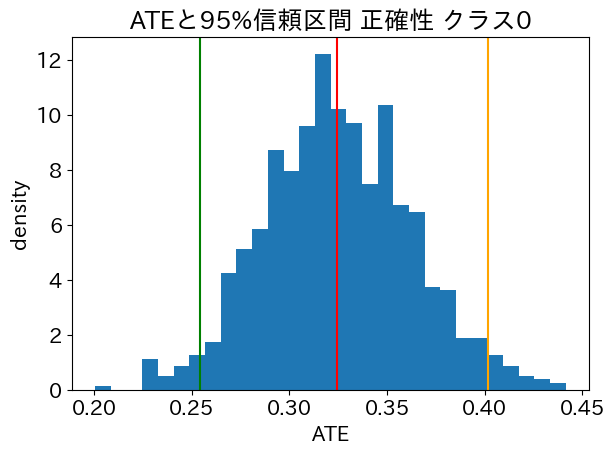

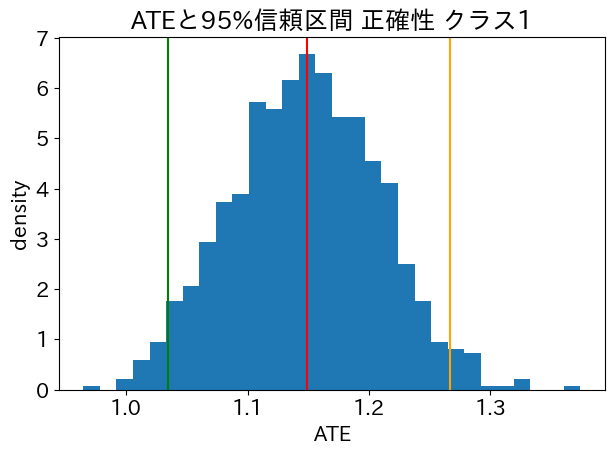

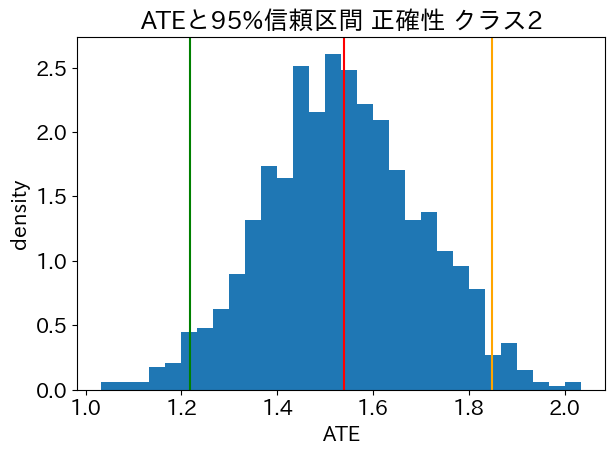

In [350]:
res_if_seg = plot_if_guard_seg(
    A0, Y0, score, nuis, seg0,
    cap=100, B=1000, seed=123, bins=30
)

In [351]:
idx0 = (seg0 == 2)
raw_diff = Y0[idx0 & (A0==1)].mean() - Y0[idx0 & (A0==0)].mean()
Y1 = Y0[idx0 & (A0==1)].mean()
Y0m = Y0[idx0 & (A0==0)].mean()
raw_diff, Y1, Y0m

(0.6209677419354835, 3.4919354838709675, 2.870967741935484)

In [352]:
def oc_dr_cdf_by_seg(A, Y, nuis, seg, cap=None, level_labels=None):
    """
    クラス別 DR-CDF（F1-F0）を計算して DataFrame で返す。
    - A: (n,) treatment 0/1
    - Y: (n,) outcome を 0..K-1 にエンコードしたもの（あなたのYと同じ）
    - nuis: fit_cf_oc の戻り（e_hat, p_hat1, p_hat0 が必要）
    - seg: (n,) クラスID（0,1,2...）
    - cap: IF-guard（例: if_g=100）。Noneならトリムしない
    - level_labels: x軸ラベル（例：levels_sorted）。無ければ 0..K-1 を使う
    """
    A = np.asarray(A).astype(int).ravel()
    Y = np.asarray(Y).astype(int).ravel()
    seg = np.asarray(seg).astype(int).ravel()

    e  = np.clip(np.asarray(nuis["e_hat"]), 1e-4, 1-1e-4)
    p1 = np.asarray(nuis["p_hat1"])   # (n,K)
    p0 = np.asarray(nuis["p_hat0"])   # (n,K)
    
    K  = p1.shape[1]

    # 予測CDF（単調）
    F1 = np.cumsum(p1, axis=1)  # (n,K)
    F0 = np.cumsum(p0, axis=1)

    # IF-guard 重み
    if cap is None:
        w1 = A / e
        w0 = (1 - A) / (1 - e)
    else:
        w1 = np.minimum(1.0 / e, cap) * A
        w0 = np.minimum(1.0 / (1.0 - e), cap) * (1 - A)

    # x軸ラベル（元のカテゴリ値）を付けたい場合
    if level_labels is None:
        th = np.arange(K)
    else:
        th = np.asarray(level_labels)

    rows = []
    for g in np.unique(seg):
        idx_g = (seg == g)
        n_g = int(idx_g.sum())
        if n_g == 0:
            continue

        # overlapチェック（任意：危険なクラスはスキップしたい場合）
        n1 = int(((A == 1) & idx_g).sum())
        n0 = int(((A == 0) & idx_g).sum())
        # 必要なら下の条件でcontinue
        # if min(n1, n0) < 10:
        #     continue

        for c in range(K):
            Zc = (Y <= c).astype(float)      # 観測のI(Y<=c)
            mu1_c = F1[:, c]                 # 予測 F1(c|X)
            mu0_c = F0[:, c]                 # 予測 F0(c|X)

            # DR補正（個体別）
            psi1 = mu1_c + w1 * (Zc - mu1_c)
            psi0 = mu0_c + w0 * (Zc - mu0_c)
            F1g = psi1[idx_g].mean()
            F0g = psi0[idx_g].mean()
            F1g = float(np.clip(F1g, 0.0, 1.0))
            F0g = float(np.clip(F0g, 0.0, 1.0))
            score_c = psi1 - psi0

            # クラス内平均＆SE（EIFの分散/ n）
            tau = F1g - F0g
            phi = score_c[idx_g] - float(score_c[idx_g].mean())
            se  = float(np.sqrt(np.mean(phi**2) / n_g))
            
            if float(psi1[idx_g].mean()) <= 0.00000:
                float(psi1[idx_g].mean()) == 0.00000

            rows.append({
                "seg": int(g),
                "c": int(c),
                "threshold": th[c],
                "n": n_g,
                "n_treat1": n1,
                "n_treat0": n0,
                "F1_dr": float(F1g),
                "F0_dr": float(F0g),
                "tau_c": tau,
                "se_c": se,
                "ci_low": tau - 1.96*se,
                "ci_high": tau + 1.96*se,
            })
    return pd.DataFrame(rows)

In [353]:
seg = data["seg_opt"].to_numpy()    # クラス列（しきい値分割で作ったもの）
A   = data["treatment"].to_numpy()
# Y は 0..K-1 にエンコード済みのあなたの Y を使う
# levels_sorted も既にあるはず（元の1..5など）

# if_c = 25
cdf_seg = oc_dr_cdf_by_seg(
    A=A0, Y=Y0, nuis=nuis, seg=seg0,
    cap=None,                 # IF-guard使うなら。使わないなら cap=None
    level_labels=levels_sorted  # x軸に元カテゴリを出したい場合
)

print(cdf_seg)

    seg  c  threshold    n  n_treat1  n_treat0     F1_dr     F0_dr     tau_c  \
0     0  0          1  912       270       642  0.000000  0.004436 -0.004436   
1     0  1          2  912       270       642  0.004410  0.020780 -0.016369   
2     0  2          3  912       270       642  0.108307  0.340579 -0.232272   
3     0  3          4  912       270       642  0.901437  0.972373 -0.070936   
4     0  4          5  912       270       642  1.000000  1.000000  0.000000   
5     1  0          1  258        14       244  0.004608  0.038885 -0.034277   
6     1  1          2  258        14       244  0.011464  0.121937 -0.110473   
7     1  2          3  258        14       244  0.140522  0.940184 -0.799662   
8     1  3          4  258        14       244  0.806001  1.000000 -0.193999   
9     1  4          5  258        14       244  1.000000  1.000000  0.000000   
10    2  0          1  155       124        31  0.000000  0.017885 -0.017885   
11    2  1          2  155       124    

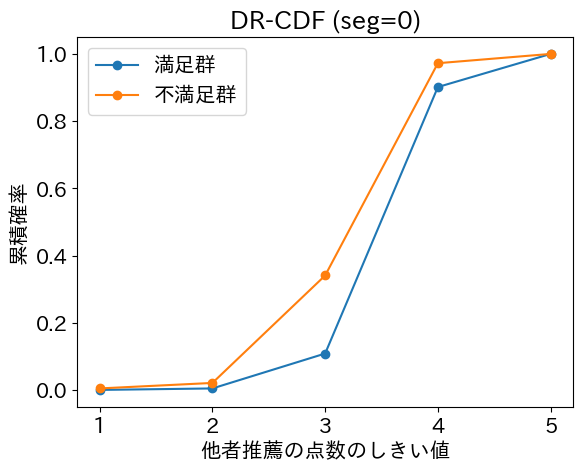

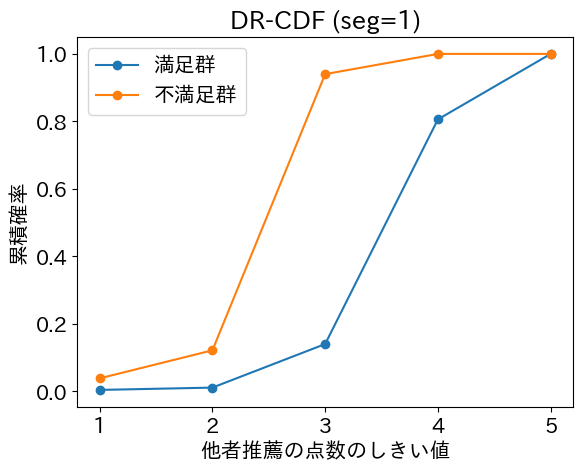

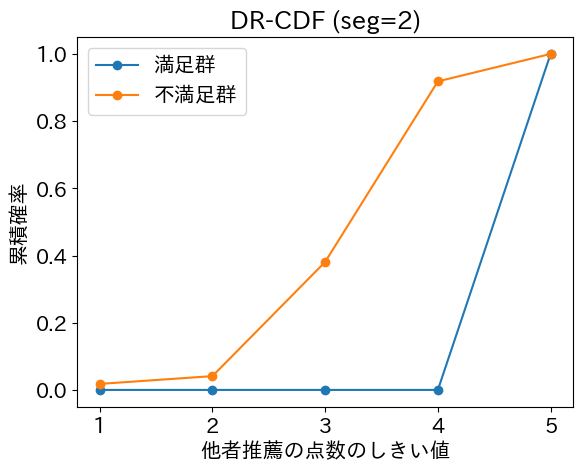

In [354]:
for g in sorted(cdf_seg["seg"].unique()):
    d = cdf_seg[cdf_seg["seg"] == g].sort_values("c")

    plt.figure()
    plt.plot(d["threshold"], d["F1_dr"], marker="o", label="満足群")
    plt.plot(d["threshold"], d["F0_dr"], marker="o", label="不満足群")
    plt.xlabel("他者推薦の点数のしきい値")
    plt.ylabel("累積確率")
    plt.title(f"DR-CDF (seg={g})")
    plt.legend()
    plt.show()

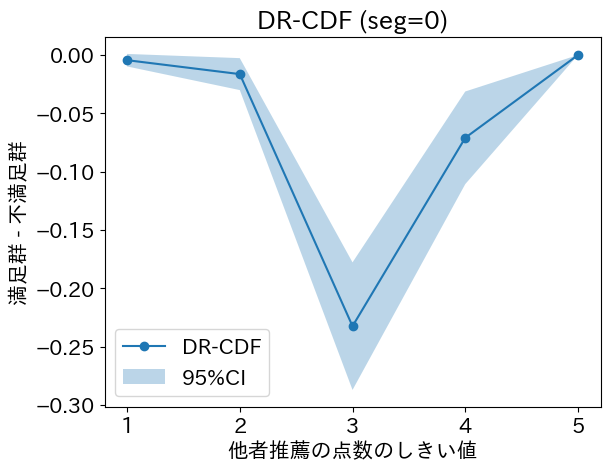

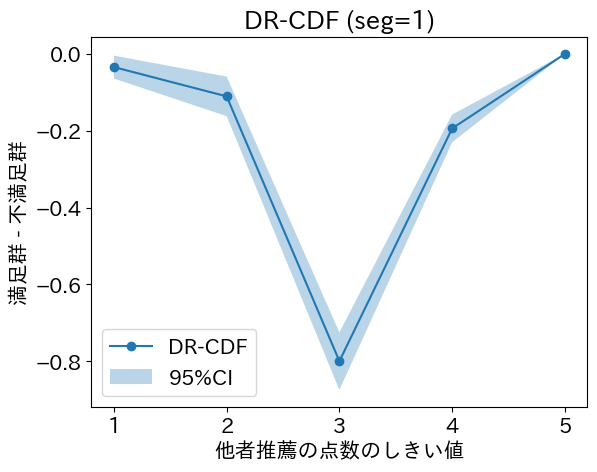

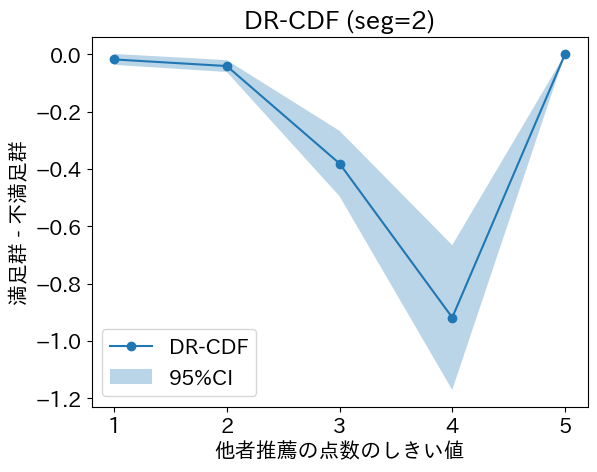

In [355]:
for g in sorted(cdf_seg["seg"].unique()):
    d = cdf_seg[cdf_seg["seg"] == g].sort_values("c")

    plt.figure()
    plt.plot(d["threshold"], d["tau_c"], marker="o", label="DR-CDF")
    plt.fill_between(d["threshold"], d["ci_low"], d["ci_high"], alpha=0.3, label="95%CI")
    plt.xlabel("他者推薦の点数のしきい値")
    plt.ylabel("満足群 - 不満足群")
    plt.title(f"DR-CDF (seg={g})")
    plt.legend()
    plt.show()

In [356]:
score_arr = np.asarray([0, 1, 2, 3, 4], dtype=float)
Z0 = score_arr[Y0]

# nuis(辞書)から予測値を取り出し、極端な傾向スコアをクリップ
e0 = np.clip(nuis["e_hat"], 1e-4, 1 - 1e-4)
mu1_0 = nuis["mu1_hat"]
mu0_0 = nuis["mu0_hat"]

# AIPWスコア（個人の擬似アウトカム）を1次元配列として計算
aipw_pseudo_outcomes = (mu1_0 - mu0_0) + (A0 / e0) * (Z0 - mu1_0) - ((1 - A0) / (1 - e0)) * (Z0 - mu0_0)
cluster_scores = tau_hat

In [357]:
from sklearn.linear_model import Ridge

# 1. すでに計算済みの擬似アウトカムを目的変数として、Ridge回帰を学習
# ※ X1 は因果クラスタリング等に使った特徴量のデータフレーム（または配列）
linear_causal_model = Ridge(alpha=1.0, random_state=123)
linear_causal_model.fit(X1, aipw_pseudo_outcomes)

feature_names = [f"Feature_{i}" for i in range(X1.shape[1])]

# 3. 解釈性の確認（論文の考察に書ける「変数の重要度」）
# ※ X1がDataFrameの場合、どの変数が効果にプラス/マイナスに効いているか一目で分かります
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": linear_causal_model.coef_})
print(coef_df.sort_values(by="Coefficient", ascending=False))

       Feature  Coefficient
2    Feature_2     0.039189
10  Feature_10     0.023187
11  Feature_11     0.016985
4    Feature_4     0.008743
12  Feature_12     0.007287
5    Feature_5     0.005915
1    Feature_1     0.002331
7    Feature_7     0.002071
6    Feature_6     0.000674
3    Feature_3    -0.007572
8    Feature_8    -0.019882
9    Feature_9    -0.020087
0    Feature_0    -0.177117


In [358]:
def calculate_heterogeneity_score(pseudo_outcomes, predicted_scores):
    """
    ユーザーを予測スコアで10等分（デシル）し、
    セグメント間ATEの【不偏分散】をHeterogeneity Scoreとして計算する関数
    """
    # 1. スコアが高い順（降順）に並べ替え
    order = np.argsort(predicted_scores)[::-1]
    sorted_outcomes = pseudo_outcomes[order]
    
    # 2. 10等分に分割
    deciles = np.array_split(sorted_outcomes, 10)
    
    # 3. 各デシル（グループ）の平均因果効果（ATE）を計算
    ates = [np.mean(d) for d in deciles]
    
    # 4. デシル間ATEの【不偏分散（Variance）】を計算
    # ddof=1 とすることで学術統計で一般的な「不偏分散」になります
    heterogeneity_score = np.var(ates, ddof=1)
    
    return heterogeneity_score

# =========================================================
# 各モデルのHeterogeneity Scoreを算出
# =========================================================
# score_proposed = calculate_heterogeneity_score(aipw_pseudo_outcomes, -S0)
score_cluster = calculate_heterogeneity_score(aipw_pseudo_outcomes, cluster_scores)
# 論文の本文や表（Table）にそのまま載せられるようにDataFrame化
heterogeneity_results = pd.DataFrame({
    "Method": [
        "Causal Clustering (RF)", 
    ],
    "Heterogeneity Score (ATE Variance)": [
        score_cluster, 
    ]
})

print("==== Heterogeneity Score (Evaluation of Segmentation Quality) ====")
print(heterogeneity_results.to_string(index=False))

==== Heterogeneity Score (Evaluation of Segmentation Quality) ====
                Method  Heterogeneity Score (ATE Variance)
Causal Clustering (RF)                            0.255479


In [359]:
smd_num = (
    sum(
        row["n"] * row["seg_mean_abs_SMD"]
        for row in per_seg_summary
    )
    /
    sum(
        row["n"]
        for row in per_seg_summary
    )
)
score_cluster /= smd_num
print(score_cluster)

3.1007619303123373


In [360]:
# tau_hat を CSV として保存
pd.DataFrame({"tau_hat": tau_hat}).to_csv("tau_hat_export.csv", index=False)